In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.spatial import cKDTree

In [2]:
data = pd.read_csv("data/xy_data.csv")

print("Dataset Shape:", data.shape)
print("\nColumns:", data.columns.tolist())

data.head()

Dataset Shape: (1500, 2)

Columns: ['x', 'y']


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


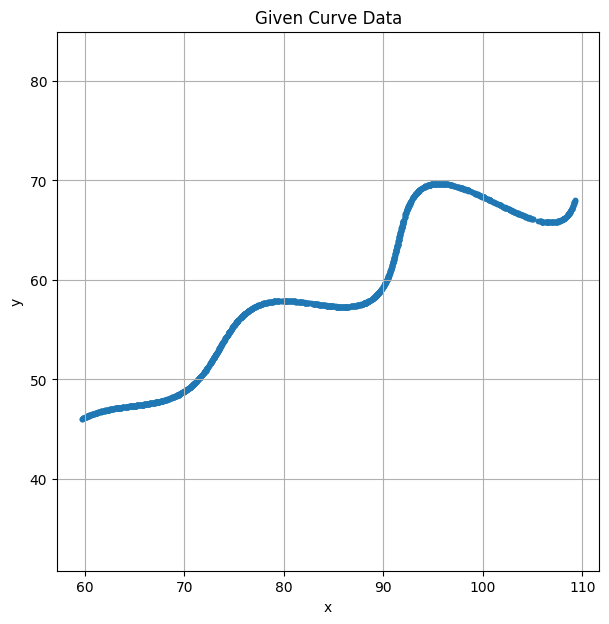

In [4]:
plt.figure(figsize=(7,7))
plt.scatter(data.iloc[:,0], data.iloc[:,1], s=10)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Given Curve Data")
plt.axis("equal")
plt.grid(True)
plt.show()

In [6]:
def parametric_curve(t, theta, M, X):
    """
    Generate x(t) and y(t) for the given parameters.
    theta should be in radians.
    """

    x = (t*np.cos(theta)-np.exp(M*np.abs(t))*np.sin(0.3*t)*np.sin(theta)+X)

    y = (42+t*np.sin(theta)
        + np.exp(M * np.abs(t)) * np.sin(0.3 * t) * np.cos(theta)
    )

    return x, y

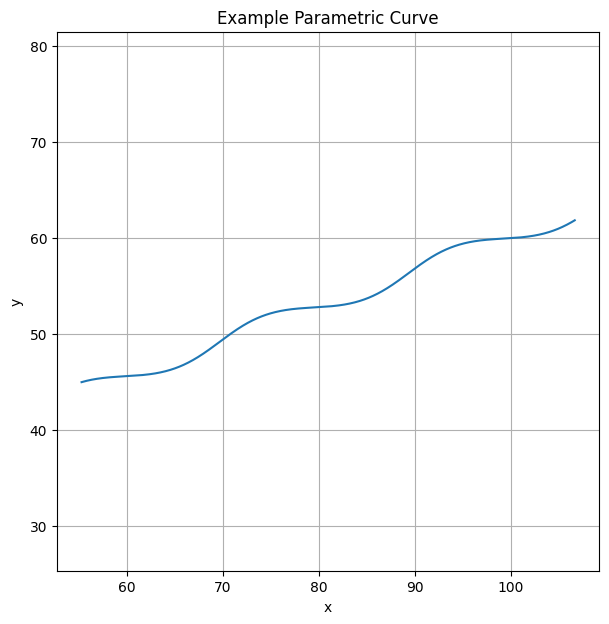

In [7]:
t = np.linspace(6, 60, 1000)

theta = np.deg2rad(20)
M = 0.0
X = 50

x_test, y_test = parametric_curve(t, theta, M, X)

plt.figure(figsize=(7,7))
plt.plot(x_test, y_test)

plt.title("Example Parametric Curve")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)

plt.show()

In [17]:
def loss_function(params):
    theta, M, X = params

    t = np.linspace(6, 60, 3000)

    x_pred, y_pred = parametric_curve(t, theta, M, X)

    predicted_points = np.column_stack((x_pred, y_pred))
    actual_points = data[["x", "y"]].values

    tree = cKDTree(predicted_points)

    _, indices = tree.query(actual_points)

    nearest_points = predicted_points[indices]

    l1_distance = np.abs(actual_points - nearest_points).sum(axis=1)

    return np.sum(l1_distance)

In [18]:
# Parameter bounds
bounds = [
    (np.deg2rad(0), np.deg2rad(50)),   # theta (radians)
    (-0.05, 0.05),                     # M
    (0, 100)                           # X
]

In [19]:
print("Running Differential Evolution...")

result = differential_evolution(
    loss_function,
    bounds=bounds,
    strategy="best1bin",
    maxiter=100,
    popsize=20,
    tol=1e-7,
    polish=False,
    seed=42
)

print("Optimization Finished!")
print(result)

Running Differential Evolution...
Optimization Finished!
             message: Optimization terminated successfully.
             success: True
                 fun: 10.371581864080355
                   x: [ 5.236e-01  3.000e-02  5.500e+01]
                 nit: 69
                nfev: 4200
          population: [[ 5.236e-01  3.000e-02  5.500e+01]
                       [ 5.236e-01  3.000e-02  5.500e+01]
                       ...
                       [ 5.236e-01  3.000e-02  5.500e+01]
                       [ 5.236e-01  3.000e-02  5.500e+01]]
 population_energies: [ 1.037e+01  1.037e+01 ...  1.037e+01  1.037e+01]


In [20]:
from scipy.optimize import minimize

In [21]:
print("Refining solution...")

refined = minimize(
    loss_function,
    result.x,
    method="L-BFGS-B",
    bounds=bounds
)

theta, M, X = refined.x

print("Refinement Finished!")

Refining solution...
Refinement Finished!


In [22]:
print("="*50)

print(f"Theta (degrees): {np.degrees(theta):.6f}")
print(f"M              : {M:.8f}")
print(f"X              : {X:.6f}")

print("="*50)

print("Final Loss:", refined.fun)

Theta (degrees): 30.000004
M              : 0.03000068
X              : 54.999999
Final Loss: 10.371581837269922


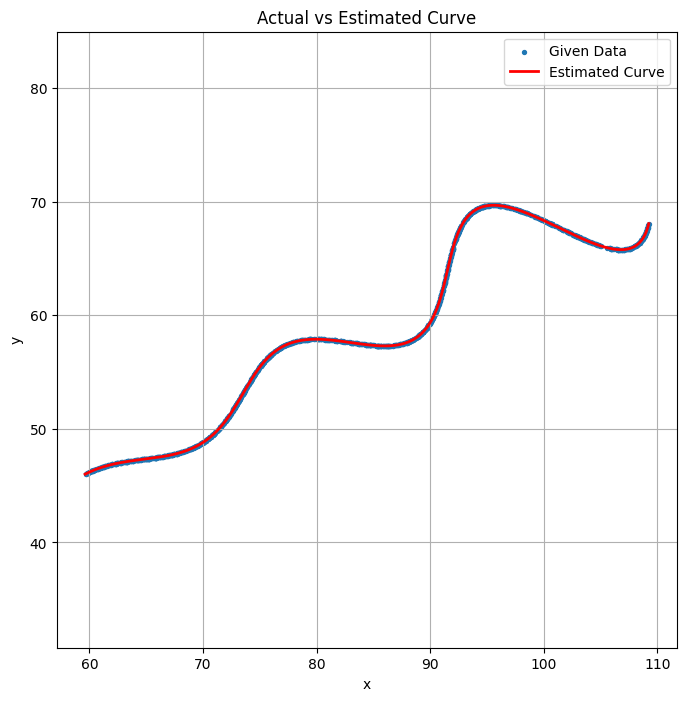

In [23]:
t = np.linspace(6, 60, 3000)

x_fit, y_fit = parametric_curve(t, theta, M, X)

plt.figure(figsize=(8,8))

plt.scatter(
    data["x"],
    data["y"],
    s=8,
    label="Given Data"
)

plt.plot(
    x_fit,
    y_fit,
    color="red",
    linewidth=2,
    label="Estimated Curve"
)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Actual vs Estimated Curve")

plt.axis("equal")
plt.grid(True)
plt.legend()

plt.show()

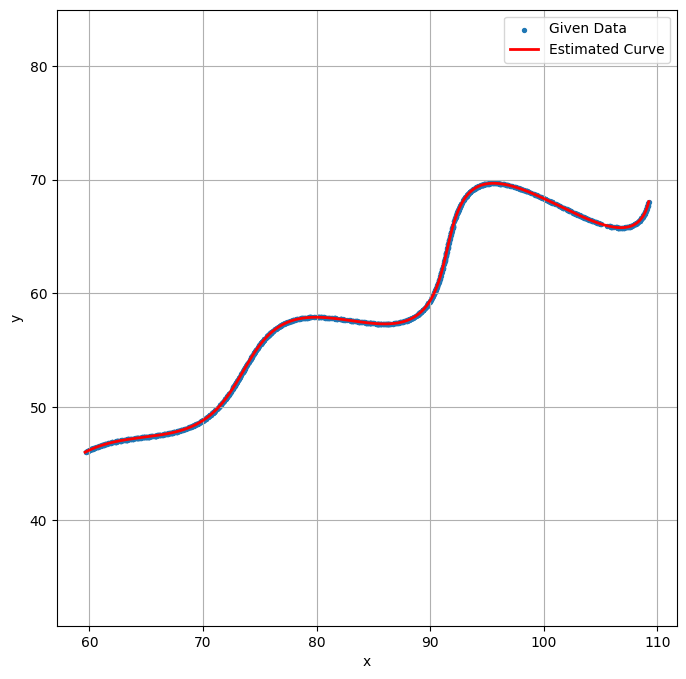

In [24]:
plt.figure(figsize=(8,8))

plt.scatter(data["x"], data["y"], s=8, label="Given Data")
plt.plot(x_fit, y_fit, color="red", linewidth=2, label="Estimated Curve")

plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.grid(True)
plt.legend()

plt.savefig("plots/fitted_curve.png", dpi=300)

plt.show()